<a href="https://colab.research.google.com/github/GDIAMEL/GLOBAL_EV_ANALYSIS/blob/main/EV_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GLOBAL EV DATA ANALYSIS**

# **IMPORTING LIBRARIES**

In [ ]:
# here are the libraries that will be in use during this analysis project
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

# **LOADING THE DATA**

In [ ]:
df = pd.read_csv("/content/IEA Global EV Data 2024.csv")

# **EXPLORING THE DATASET**

In [ ]:
# Assessing the data information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12654 entries, 0 to 12653
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      12654 non-null  object 
 1   category    12654 non-null  object 
 2   parameter   12654 non-null  object 
 3   mode        12654 non-null  object 
 4   powertrain  12654 non-null  object 
 5   year        12654 non-null  int64  
 6   unit        12654 non-null  object 
 7   value       12654 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 791.0+ KB


In [ ]:
#Assessing the top five of the dataset

df.head()

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [30]:
# the highest value in the dataset
df.loc[df['value'].idxmax()]

,12609
region,World
category,Projection-APS
parameter,EV stock
mode,Cars
powertrain,BEV
year,2035
unit,Vehicles
value,440000000.0


In [32]:
# the least value in the dataset
df.loc[df['value'].idxmin()]

,8359
region,Rest of the world
category,Historical
parameter,Oil displacement Mbd
mode,Trucks
powertrain,EV
year,2012
unit,Milion barrels per day
value,0.000001


In [ ]:
# Assessing the last five of the dataset

df.tail()

,region,category,parameter,mode,powertrain,year,unit,value
12649,World,Projection-STEPS,EV sales share,Cars,EV,2035,percent,55.0
12650,World,Projection-STEPS,EV stock share,Cars,EV,2035,percent,31.0
12651,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,9400000.0
12652,World,Projection-APS,EV charging points,EV,Publicly available slow,2035,charging points,15000000.0
12653,World,Projection-STEPS,EV stock share,Trucks,EV,2035,percent,9.0


In [ ]:
# viewing the number of rows and columns in  the dataset

df.shape

(12654, 8)

In [ ]:
# Viewing the statistical summary of the dataset

df.describe()

,year,value
count,12654.000000,1.265400e+04
mean,2019.822112,4.273742e+05
std,5.476494,6.860498e+06
min,2010.000000,1.200000e-06
25%,2016.000000,2.000000e+00
50%,2020.000000,1.300000e+02
75%,2022.000000,5.500000e+03
max,2035.000000,4.400000e+08


In [ ]:
# to stop the conflict with the older version the following is necessary

!pip uninstall pandas-profiling


Found existing installation: pandas-profiling 3.2.0
Uninstalling pandas-profiling-3.2.0:
  Would remove:
    /usr/local/bin/pandas_profiling
    /usr/local/lib/python3.11/dist-packages/pandas_profiling-3.2.0.dist-info/*
    /usr/local/lib/python3.11/dist-packages/pandas_profiling/*
Proceed (Y/n)? ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/uninstall.py", line 106, in run
    uninstall_pathset = req.uninstall(
                        ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/req/req_install.py", line 722, in uninstall
    uninstalled_pathset.remove(auto_confirm, verbose)
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/req/req_uninstall.py", line 364, in remove
    if auto

In [ ]:
# Lets use pandas profiling for a final data exploration

!pip install ydata-profiling

In [19]:
# continuing with the profiling data report after the install

from pandas_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='PANDAS_PROFILING_REPORT')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 18.36it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/ydata_profiling/profile_report.py:386: UserWarning: Extension  not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **DATA CLEANING**

In [20]:
# Checking for duplicates in the dataset

df.duplicated().sum()

np.int64(0)

In [21]:
# Checking for missing values in the dataset

df.isnull().sum()

,0
region,0
category,0
parameter,0
mode,0
powertrain,0
year,0
unit,0
value,0


Since we have noted that there are no duplicates or missing values in the dataset, we will head to data visualization for the dataset

# **DATA VISUALIZATION**

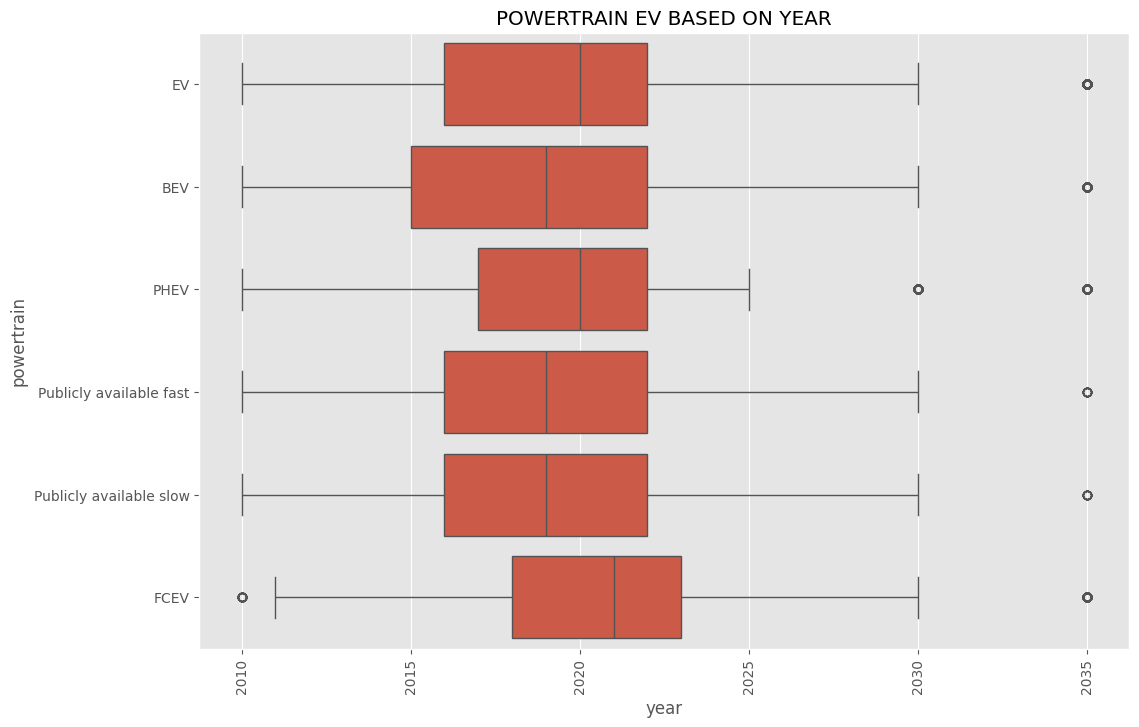

In [24]:
#Checking for outliers in maize production total
plt.style.use('ggplot')
# creating the plot
plt.figure(figsize=(12,8))
sns.boxplot(x='year', y='powertrain', data=df)
# labeling and saving the plot
plt.title('POWERTRAIN EV BASED ON YEAR')
plt.xticks(rotation=90)
plt.savefig('EV.PNG')
plt.show()

**OVERVIEW OF THE ABOVE**

The above boxplot illustrates the timeline of adoption and development across various electric vehicle (EV) powertrains and charging infrastructures, showing significant growth from around 2014 to 2024. Battery Electric Vehicles (BEVs), Plug-in Hybrid Electric Vehicles (PHEVs), and public charging stations dominate this period, reflecting mainstream adoption and infrastructure expansion. Notably, Fuel Cell Electric Vehicles (FCEVs) appear more recently in the timeline, indicating their emerging status in the market. Outliers extending to 2035 suggest future planning and projections, emphasizing the ongoing evolution and long-term commitment to electric mobility.









In [26]:
# lets do a mean for the value section of the dataset
df['value'].mean()

np.float64(427374.1734977358)

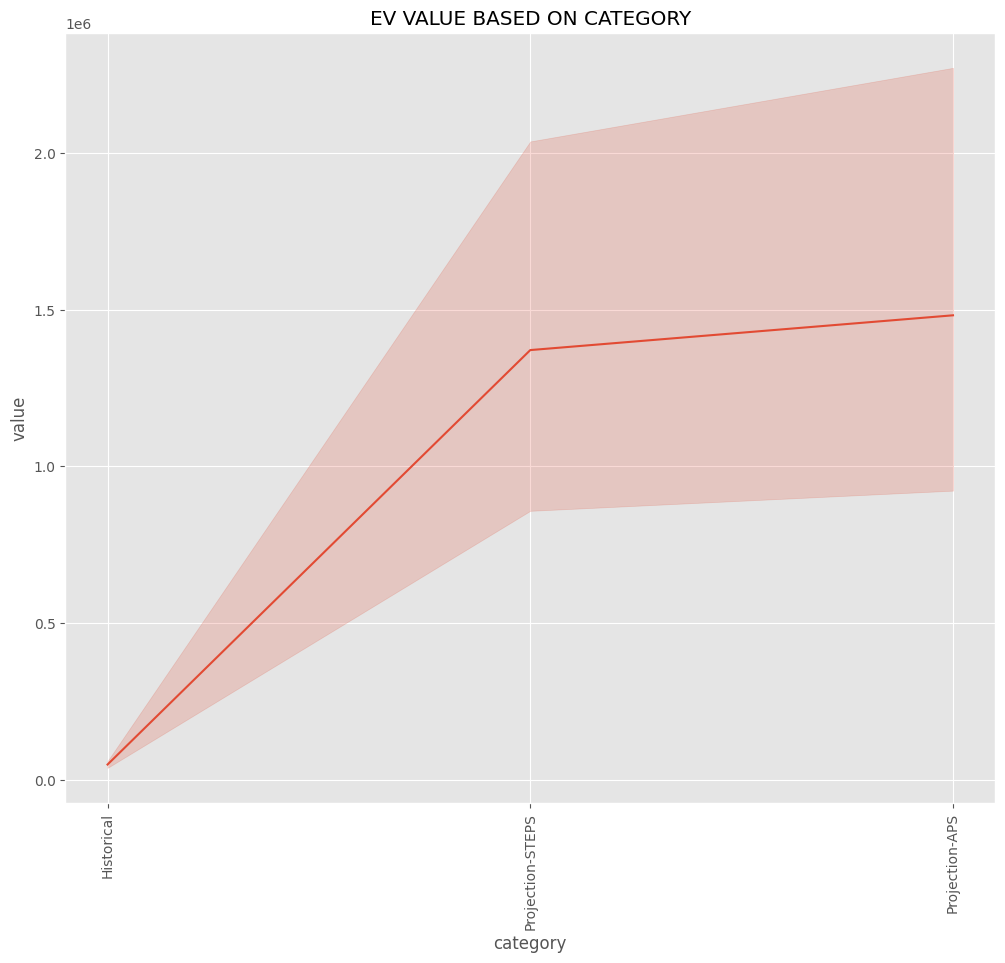

In [34]:
# plotting a line graph
fig, ax = plt.subplots(figsize=(12,10))
sns.lineplot(x='category', y='value', data=df)
# Labeling
plt.title('EV VALUE BASED ON CATEGORY')
plt.xticks(rotation=90)
plt.show()

In [27]:
# Finding correlation in the data
df.corr(numeric_only=True)

,year,value
year,1.000000,0.120782
value,0.120782,1.000000


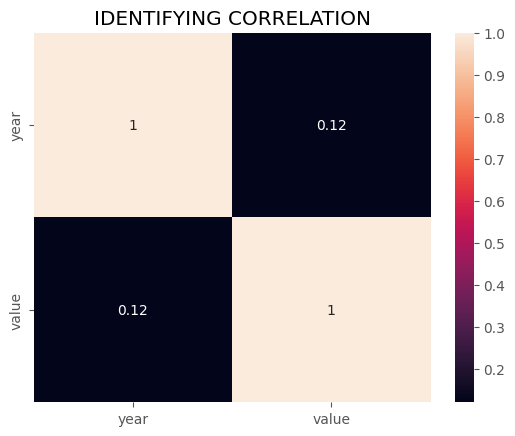

In [28]:
# for the above data here is a visual representation of it
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('IDENTIFYING CORRELATION')
plt.savefig('CORRELATION.png')
plt.show()

**OVERVIEW OF THE ABOVE**

The heatmap above shows the correlation matrix between two variables: year and value.

Key Analysis:
The correlation coefficient between year and value is 0.12, indicating a very weak positive correlation.

A value close to 0 suggests that there is little to no linear relationship between the two variables.

In practical terms, this means that changes in the year are not strongly associated with changes in the value being measured.

Conclusion:
There is no significant linear relationship between the year and the value in this dataset. This implies that time progression alone does not meaningfully predict or influence the values in question—at least not in a simple linear manner.
